In [3]:
import pandas as pd 

In [6]:
#Import the data
df = pd.read_csv('customer_insights.csv')

In [19]:
## Explore the data: 

df.head()

,CustomerID,Age,SpendCategory,TransactionAmount,ProductCategory
0,90166,65,High,484.396933,Electronics
1,41361,49,Low,185.815288,Electronics
2,96044,47,Medium,178.332958,Electronics
3,87539,19,Medium,444.878793,Clothing
4,70709,25,Low,807.684483,Home


Notes: 
- Not sure what SpendCategory defines, as you can see for row 4 that the TransactionAmount is 807 and it has SpendCategory "Low" while other rows have much lower TransactionAmount but are in Med or High.
- Everything else looks alright

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   SpendCategory      10000 non-null  str    
 3   TransactionAmount  10000 non-null  float64
 4   ProductCategory    10000 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 390.8 KB


- no null values
- All dtypes looks correct

In [10]:
df.describe()

,CustomerID,Age,TransactionAmount
count,10000.000000,10000.000000,10000.000000
mean,54942.155300,43.650600,403.034919
std,25945.926887,14.970756,284.507334
min,10002.000000,18.000000,1.287571
25%,32453.000000,31.000000,194.324808
50%,55142.500000,44.000000,338.779355
75%,77117.000000,57.000000,544.877547
max,99997.000000,69.000000,2537.036820


- Everything looks all right here.
- Age range is 18-69
- Spending range is 1.27 - 2,537
- CustomerID ranges from 10002 to 99997. Since there are only 10,000 rows, the IDs are not sequential, meaning they do not simply increase by 1 for each new customer.

In [13]:
# seeing each Category type

all_categroies = df['ProductCategory'].unique()
all_categroies

<StringArray>
['Electronics', 'Clothing', 'Home', 'Beauty']
Length: 4, dtype: str

- Looks good, only four categories. 

In [17]:
# Seeing if there are any repeat customers: 

print(f"There are {df['CustomerID'].nunique()} unique Customer IDs out of {df['CustomerID'].count()} total entries.")


There are 9473 unique Customer IDs out of 10000 total entries.


- That means that there are some repeat customers
- I think it will be intresting to visualize the amount of repeat customers and how many times they returned.
- Note that the repeat customers are a very small part of the business. 

In [ ]:
- There arent that many 

## Understanding SpendCategory - groupby()

I saw above that SpendCategory doesnt seem to be corilated with TransactionAmount. I want to find out if that was an error or if its calculated in some other way. 

In [20]:
df.groupby("SpendCategory")["TransactionAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
SpendCategory,,,,,,,,
High,3291.0,400.718294,284.685283,1.409882,193.586438,331.396779,547.008171,1916.639218
Low,3326.0,403.505778,277.048102,4.883557,195.281060,344.718371,549.229196,2234.450689
Medium,3383.0,404.825619,291.553231,1.287571,193.631383,337.909176,536.712382,2537.036820


- From this, we can see that the range for each SpendCategory is almost the same.

- The same is true for the mean, with all categories averaging around 400.

Does this mean that SpendCategory is miscalculated, or is it measuring something else?

# Visualization 

There are a two topics I want to investigate: 
1) Is SpendCategory miscalulated or mesuring some other metric?
2) The habbits of the returning customers, how much do they spend, and how many times did they return.

## SpendCategory:  

Lets visualize SpendCategory:

1) SpendCategory for each ProductCategory and each Age range. 
2) Each SpendCategory on its own chart to see its distrubution, I am guessing from the describe we did above that they all look the same since the mean and range was the same but might as well double check. 

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

### Lets see the distrubution for each spend category 

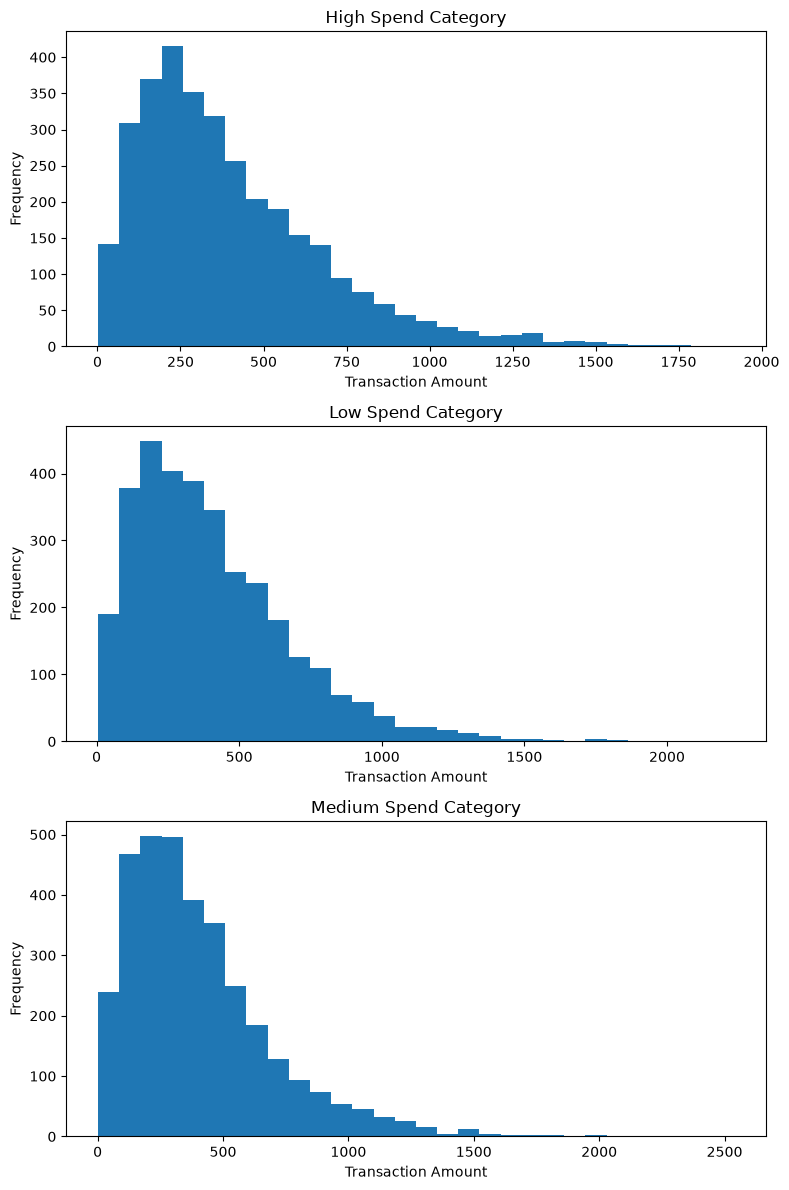

In [34]:
categories = df["SpendCategory"].unique()

fig, axes = plt.subplots(
    len(categories),
    1,
    figsize=(8, 4 * len(categories))
)

for ax, category in zip(axes, categories):

    category_data = df.loc[
        df["SpendCategory"] == category,
        "TransactionAmount"
    ]

    ax.hist(category_data, bins=30)

    ax.set_title(f"{category} Spend Category")
    ax.set_xlabel("Transaction Amount")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Seems that it's almost the same for all SpendCategory.
- Lets see if SpendCategory is SpendCategory by ProductCategory. Meaning that each prouct category has a unique spending categories:
  

In [26]:


product_spend = (
    df.groupby(["ProductCategory", "SpendCategory"])["TransactionAmount"]
      .mean()
      .reset_index()
)

product_spend

,ProductCategory,SpendCategory,TransactionAmount
0,Beauty,High,399.179398
1,Beauty,Low,402.468022
2,Beauty,Medium,394.282708
3,Clothing,High,377.721403
4,Clothing,Low,406.408149
5,Clothing,Medium,426.898940
6,Electronics,High,419.703551
7,Electronics,Low,399.544422
8,Electronics,Medium,399.727772
9,Home,High,405.497472


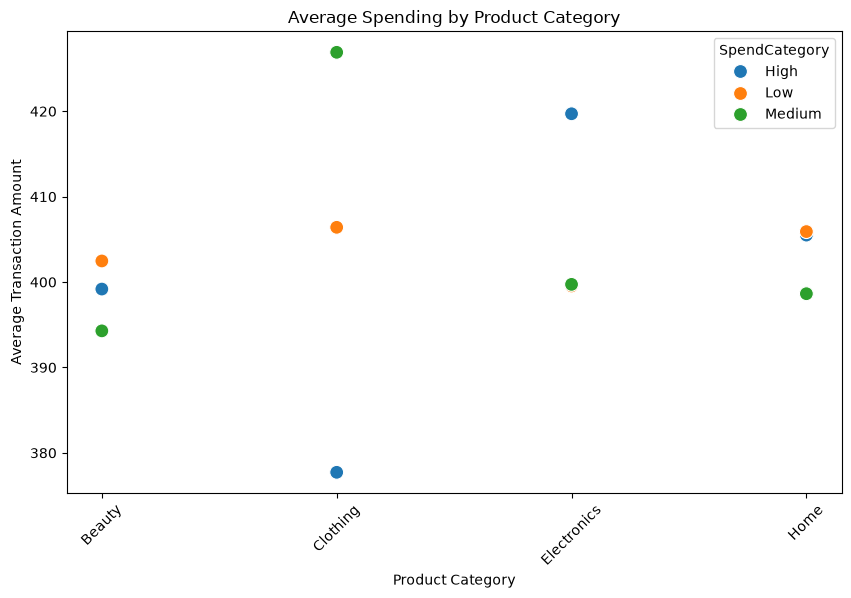

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_spend,
    x="ProductCategory",
    y="TransactionAmount",
    hue="SpendCategory",
    s=100
)

plt.title("Average Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=45)

plt.show()

### From here, I can see that SpendCategory is not tied to ProductCategory.

- For none of the Product Categories does the average spending for each SpendCategory line up properly. You can see that the blue dot is never the highest one.

#### Let's move on to seeing whether it lines up with Age Category or not.


In [35]:
#Lets make buckets for each age group, more buckets mean more granulity, since we dont know how the creaters of the dataset would have grouped ages: 
df["AgeRange"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

In [36]:
age_spend = (
    df.groupby(
        ["AgeRange", "SpendCategory"],
        observed=True
    )["TransactionAmount"]
    .mean()
    .reset_index()
)

age_spend

,AgeRange,SpendCategory,TransactionAmount
0,<25,High,410.311009
1,<25,Low,385.710967
2,<25,Medium,397.086777
3,25-34,High,390.666693
4,25-34,Low,407.416932
5,25-34,Medium,417.941068
6,35-44,High,392.890600
7,35-44,Low,395.720076
8,35-44,Medium,393.971715
9,45-54,High,396.620015


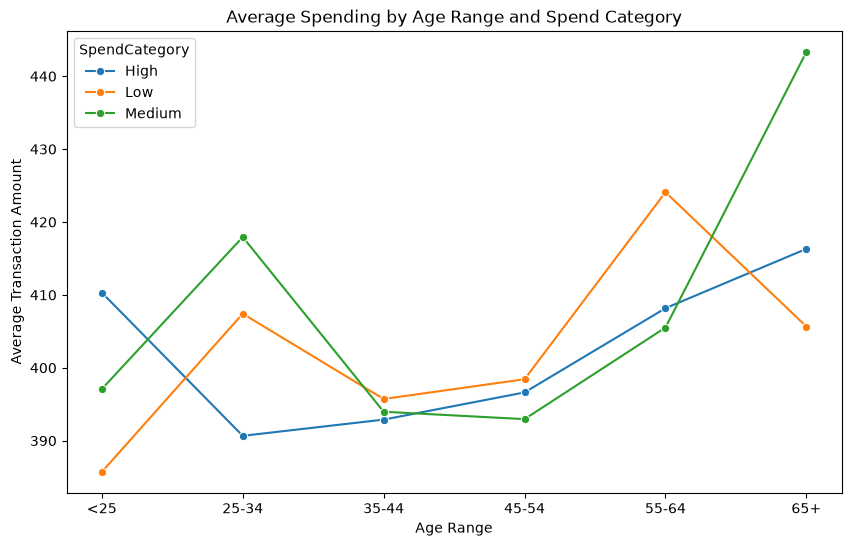

In [37]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=age_spend,
    x="AgeRange",
    y="TransactionAmount",
    hue="SpendCategory",
    marker="o"
)

plt.title("Average Spending by Age Range and Spend Category")
plt.xlabel("Age Range")
plt.ylabel("Average Transaction Amount")

plt.show()

### Again we can see its not corilated

- I tried a diffrent chart this time that makes it easier to see that SpendCategory is not consistent here. 

## Returning Customers 

- Lets visualize the returning customers to see if there are any trends. 

In [42]:
customer_visits = (
    df.groupby("CustomerID")
      .size()
      .reset_index(name="VisitCount")
)

returning_customers = customer_visits[
    customer_visits["VisitCount"] > 1
].copy()

returning_customers["ReturnCount"] = (
    returning_customers["VisitCount"] - 1
)

returning_customers.head()

,CustomerID,VisitCount,ReturnCount
37,10421,2,1
52,10623,2,1
56,10657,2,1
73,10774,2,1
148,11418,2,1


In [43]:
# making buckets for visualization

return_buckets = (
    returning_customers
    .groupby("ReturnCount")
    .size()
    .reset_index(name="CustomerCount")
)

return_buckets

,ReturnCount,CustomerCount
0,1,486
1,2,19
2,3,1


## The data here is pretty simple and I dont think it needs any visualzition, so I will skip that here. 

- The data shows that there are only ~5% returning customers, and that most of them came back only 1 time.
- And a negligable amount of customers that returned more than that. 

In [44]:
# Interactive chart; 

In [45]:
import plotly.express as px

age_spending = (
    df.groupby("AgeRange", observed=True)
      .agg(
          AverageSpending=("TransactionAmount", "mean"),
          Customers=("CustomerID", "nunique"),
          Transactions=("TransactionAmount", "size")
      )
      .reset_index()
)

age_spending

,AgeRange,AverageSpending,Customers,Transactions
0,<25,398.277572,1480,1495
1,25-34,405.358661,1909,1925
2,35-44,394.201963,1929,1953
3,45-54,396.030092,1908,1930
4,55-64,412.674386,1887,1905
5,65+,422.032304,788,792


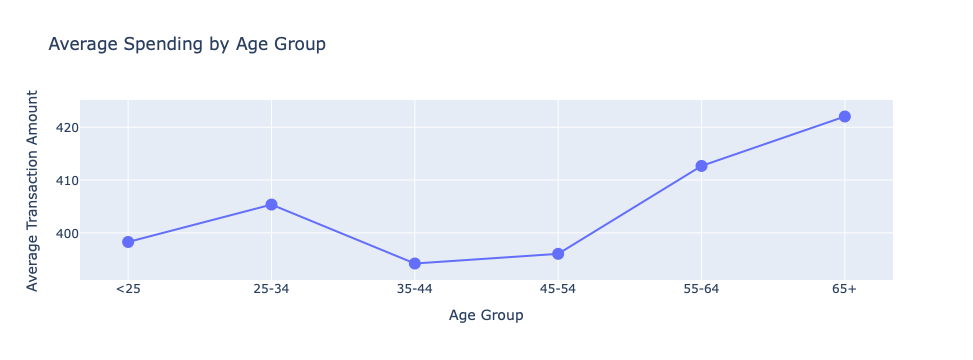

In [46]:
fig = px.line(
    age_spending,
    x="AgeRange",
    y="AverageSpending",
    markers=True,
    title="Average Spending by Age Group",
    labels={
        "AgeRange": "Age Group",
        "AverageSpending": "Average Transaction Amount"
    },
    custom_data=["Customers", "Transactions"]
)

fig.update_traces(
    marker=dict(size=12),
    hovertemplate=
        "<b>Age Group: %{x}</b><br>"
        "Average Spending: $%{y:.2f}<br>"
        "Unique Customers: %{customdata[0]}<br>"
        "Transactions: %{customdata[1]}"
        "<extra></extra>"
)

fig.show()

From this chart we see that the highest spending groups are the oldest two, with a strange low avg spending for 35-54

- Note that the highest spending age group which is 65+ (which goes until 69) is also the one with the least transactions.
- Lets view the total spent buy each group, maybe the high avg spending makes up for the low transaction amounts?

In [47]:
import plotly.express as px

age_total_spending = (
    df.groupby("AgeRange", observed=True)
      .agg(
          TotalSpending=("TransactionAmount", "sum"),
          Customers=("CustomerID", "nunique")
      )
      .reset_index()
)

age_total_spending

,AgeRange,TotalSpending,Customers
0,<25,595424.969395,1480
1,25-34,780315.422770,1909
2,35-44,769876.433179,1929
3,45-54,764338.078459,1908
4,55-64,786144.705339,1887
5,65+,334249.584417,788


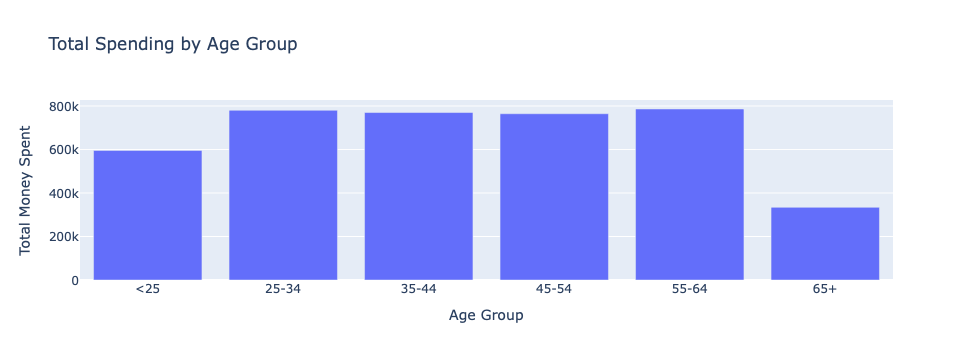

In [48]:
fig = px.bar(
    age_total_spending,
    x="AgeRange",
    y="TotalSpending",
    title="Total Spending by Age Group",
    labels={
        "AgeRange": "Age Group",
        "TotalSpending": "Total Money Spent"
    },
    custom_data=["Customers"]
)

fig.update_traces(
    hovertemplate=
        "<b>Age Group: %{x}</b><br>"
        "Total Spending: $%{y:,.2f}<br>"
        "Unique Customers: %{customdata[0]}"
        "<extra></extra>"
)

fig.show()

No it does not, this chart shows that the 25-64 age group in transaction amount is much smoother, and that 65+ didnt make up for their low transaction amounts with their high avg spending. 